# BPE Tokenizer + Retraining
Replace character-level tokenizer with BPE (vocab 8K) for coherent generation.

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F, math, time, os, json, zipfile
import matplotlib.pyplot as plt

## 1. Install + Train BPE Tokenizer

In [2]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tokenizers', '-q',
    '-i', 'https://mirrors.tuna.tsinghua.edu.cn/pypi/web/simple'])
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders
print('tokenizers ready')

tokenizers ready


In [3]:
zip_path = os.path.expanduser('~/Desktop/918822019.github.io/data/coco/PAI/COCO2017/annotations_trainval2017.zip')
with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('annotations/captions_train2017.json') as f: train = json.load(f)
    with z.open('annotations/captions_val2017.json') as f: val = json.load(f)
caps = [a['caption'].lower().strip() for a in train['annotations'] + val['annotations']]
print(f"Captions: {len(caps):,}")

tok = Tokenizer(models.BPE())
tok.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=True)
tok.decoder = decoders.ByteLevel()
trainer = trainers.BpeTrainer(vocab_size=8192, special_tokens=['<pad>','<bos>','<eos>','<unk>'],
                              min_frequency=2, show_progress=True)
tok.train_from_iterator(caps, trainer)
tok.save('bpe_tokenizer.json')
print(f"Vocab size: {tok.get_vocab_size()}")

Captions: 616,767


Vocab size: 8192


In [4]:
tok = Tokenizer.from_file('bpe_tokenizer.json')
BOS, EOS = tok.token_to_id('<bos>'), tok.token_to_id('<eos>')
v = tok.get_vocab_size()
def enc(s): return [BOS] + tok.encode(s).ids + [EOS]
def dec(ids): return tok.decode([i for i in ids if i not in (BOS, EOS)])
print(f"Sample: '{caps[0]}' -> {enc(caps[0])[:10]}...")
print(f"Decode back: '{dec(enc(caps[0]))}'")

Sample: 'a bicycle replica with a clock as the front wheel.' -> [1, 68, 863, 6612, 96, 68, 383, 450, 85, 259]...
Decode back: ' a bicycle replica with a clock as the front wheel.'


## 2. Tokenize All Data

In [5]:
all_ids = []
for cap in caps:
    all_ids.extend(enc(cap))
data = torch.tensor(all_ids, dtype=torch.long)
n1 = int(0.9 * len(data))
train_data, val_data = data[:n1], data[n1:]
print(f"Tokens: train {len(train_data):,}, val {len(val_data):,}")
del caps, all_ids

def get_batch(data, sl=128, bs=32):
    ix = torch.randint(len(data)-sl-1, (bs,))
    return torch.stack([data[i:i+sl] for i in ix]), torch.stack([data[i+1:i+sl+1] for i in ix])

Tokens: train 7,510,586, val 834,510


## 3. Model (same architecture, larger embedding)

In [6]:
def linear_attn_seq(q, k, v, decay=0.99, eps=1e-6):
    B, H, T, D = q.shape
    qf, kf, vf = F.elu(q)+1, F.elu(k)+1, F.elu(v)+1
    S = torch.zeros(B, H, D, D, device=q.device)
    z = torch.zeros(B, H, D, device=q.device)
    outs = []
    for i in range(T):
        S = decay * S + kf[:,:,i:i+1].transpose(-2,-1) @ vf[:,:,i:i+1]
        z = decay * z + kf[:,:,i]
        out = (qf[:,:,i:i+1] @ S) / (qf[:,:,i:i+1] @ z.unsqueeze(-1)).clamp(min=eps)
        outs.append(out)
    return torch.cat(outs, -2)

class RoPE(nn.Module):
    def __init__(self, dim, base=10000.0):
        super().__init__()
        inv_freq = 1.0/(base**(torch.arange(0,dim,2).float()/dim))
        self.register_buffer('inv_freq', inv_freq)
    def forward(self, x, offset=0):
        t = torch.arange(offset, offset+x.shape[-2], device=x.device).type_as(self.inv_freq)
        freqs = t.unsqueeze(-1) @ self.inv_freq.unsqueeze(0)
        return torch.cat([freqs, freqs], -1)
def apply_rope(x, emb):
    s = x.shape[-1]//2
    xc = torch.view_as_complex(x.reshape(*x.shape[:-1],s,2).contiguous())
    ec = torch.view_as_complex(emb.reshape(*emb.shape[:-1],s,2).contiguous())
    return torch.view_as_real(xc*ec).reshape(*x.shape[:-1],-1)

In [7]:
class HybridLayer(nn.Module):
    def __init__(self, dim=256, hd=64, nh=4):
        super().__init__()
        self.hd = hd; self.nh = nh
        self.csa_k = nn.Linear(dim, hd, 0); self.csa_v = nn.Linear(dim, hd, 0)
        self.csa_q = nn.Linear(dim, hd, 0); self.csa_o = nn.Linear(hd, dim, 0)
        self.hca_k = nn.Linear(dim, hd, 0); self.hca_v = nn.Linear(dim, hd, 0)
        self.hca_q = nn.Linear(dim, hd, 0); self.hca_o = nn.Linear(hd, dim, 0)
        self.swa_q = nn.Linear(dim, dim, 0); self.swa_k = nn.Linear(dim, dim, 0)
        self.swa_v = nn.Linear(dim, dim, 0); self.swa_o = nn.Linear(dim, dim, 0)
        self.norm1 = nn.LayerNorm(dim); self.norm2 = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(nn.Linear(dim, dim*4), nn.GELU(), nn.Linear(dim*4, dim))
        self.gate = nn.Parameter(torch.ones(3))
    def forward(self, h, rope_emb):
        B, T, _ = h.shape
        qc = self.csa_q(h).view(B,T,1,self.hd).transpose(1,2)
        kc = self.csa_k(h).view(B,T,1,self.hd).transpose(1,2)
        vc = self.csa_v(h).view(B,T,1,self.hd).transpose(1,2)
        oc = self.csa_o(linear_attn_seq(qc,kc,vc,0.99).squeeze(1))
        qh = self.hca_q(h).view(B,T,1,self.hd).transpose(1,2)
        kh = self.hca_k(h).view(B,T,1,self.hd).transpose(1,2)
        vh = self.hca_v(h).view(B,T,1,self.hd).transpose(1,2)
        oh = self.hca_o(linear_attn_seq(qh,kh,vh,0.999).squeeze(1))
        qs = self.swa_q(h).view(B,T,self.nh,self.hd).transpose(1,2)
        ks = self.swa_k(h).view(B,T,self.nh,self.hd).transpose(1,2)
        vs = self.swa_v(h).view(B,T,self.nh,self.hd).transpose(1,2)
        emb = rope_emb[:T] if rope_emb.shape[-2] >= T else rope_emb
        ks = apply_rope(ks, emb); qs = apply_rope(qs, emb)
        os_ = F.scaled_dot_product_attention(qs, ks, vs, is_causal=True)
        os_ = self.swa_o(os_.transpose(1,2).reshape(B,T,-1))
        g = F.softmax(self.gate, 0)
        h = self.norm1(h + g[0]*oc + g[1]*oh + g[2]*os_)
        return h + self.ffn(self.norm2(h))

class EdgeTransformer(nn.Module):
    def __init__(self, n_layers=2, dim=256, hd=64, nh=4, v=8192):
        super().__init__()
        self.embed = nn.Embedding(v, dim)
        self.rope = RoPE(hd)
        self.layers = nn.ModuleList([HybridLayer(dim, hd, nh) for _ in range(n_layers)])
        self.lm_head = nn.Linear(dim, v, 0)
        for m in self.modules():
            if isinstance(m, nn.Linear): nn.init.normal_(m.weight, 0.0, 0.02)
            if isinstance(m, nn.Linear) and m.bias is not None: nn.init.zeros_(m.bias)
            if isinstance(m, nn.Embedding): nn.init.normal_(m.weight, 0.0, 0.02)
    def forward(self, x):
        h = self.embed(x)
        rope_emb = self.rope(h)
        for layer in self.layers:
            h = layer(h, rope_emb)
        return self.lm_head(h)

## 4. Training

In [8]:
m = EdgeTransformer(n_layers=2, dim=256, hd=64, nh=4, v=v)
print(f"Params: {sum(p.numel() for p in m.parameters()):,}")
opt = torch.optim.AdamW(m.parameters(), lr=3e-4)
steps = 2000; tl, vl = [], []; t0 = time.time()
for step in range(steps):
    m.train(); x, y = get_batch(train_data, 128, 32)
    loss = F.cross_entropy(m(x).reshape(-1, v), y.reshape(-1))
    opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step()
    if step % 200 == 0:
        m.eval()
        with torch.no_grad():
            xv, yv = get_batch(val_data, 128, 32)
            lv = F.cross_entropy(m(xv).reshape(-1, v), yv.reshape(-1))
        tl.append(loss.item()); vl.append(lv.item())
        print(f"step {step:>5} | train {loss.item():.4f} | val {lv.item():.4f} | ppl {math.exp(lv.item()):.2f} | {time.time()-t0:.0f}s")

Params: 6,033,926


step     0 | train 9.1377 | val 8.7694 | ppl 6434.55 | 2s


step   200 | train 3.5518 | val 3.7499 | ppl 42.52 | 341s


step   400 | train 3.4075 | val 3.6683 | ppl 39.19 | 690s


step   600 | train 3.4102 | val 3.4539 | ppl 31.62 | 1029s


...

step  1000 | train 3.1647 | val 3.2718 | ppl 26.36 | 1725s


step  1200 | train 3.0964 | val 3.1988 | ppl 24.50 | 2070s


step  1400 | train 3.1172 | val 3.1831 | ppl 24.12 | 2408s


step  1600 | train 2.9661 | val 3.1610 | ppl 23.60 | 2755s


step  1800 | train 3.0145 | val 2.9632 | ppl 19.36 | 3105s


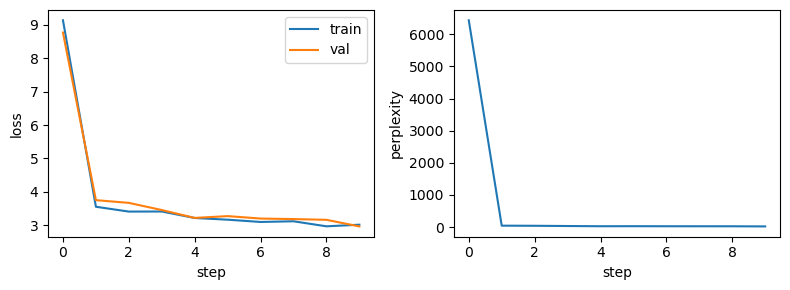

Final val loss: 2.9632, ppl: 19.36


In [9]:
plt.figure(figsize=(8,3))
plt.subplot(121); plt.plot(tl, label='train'); plt.plot(vl, label='val')
plt.xlabel('step'); plt.ylabel('loss'); plt.legend()
plt.subplot(122); plt.plot([math.exp(l) for l in vl])
plt.xlabel('step'); plt.ylabel('perplexity')
plt.tight_layout(); plt.show()
print(f"Final val loss: {vl[-1]:.4f}, ppl: {math.exp(vl[-1]):.2f}")

In [10]:
tok = Tokenizer.from_file('bpe_tokenizer.json')
BOS, EOS = tok.token_to_id('<bos>'), tok.token_to_id('<eos>')
def gen(m, prompt='a', max_n=60, temp=0.8):
    m.eval()
    ids = [BOS]
    if prompt:
        ids += tok.encode(' ' + prompt).ids
    ix = torch.tensor([ids], dtype=torch.long)
    with torch.no_grad():
        for _ in range(max_n):
            logits = m(ix[:, -512:])
            p = F.softmax(logits[:,-1]/temp, -1)
            ix = torch.cat([ix, torch.multinomial(p, 1)], -1)
            if ix[0,-1].item() == EOS: break
    return tok.decode(ix[0].tolist()).replace('<pad>','').strip()

for p in ['a', 'the', 'an', 'two', 'a group of']:
    try:
        out = gen(m, p, 40)
        print(f'{p}: {out}\n')
    except Exception as e:
        print(f'{p}: ERROR {e}')

a: a sequence of water.



the: the stove with a door lid out of it over a building



an: an elephant, one foothill

two: two cats on the ground.



a group of: a group of elephants through an open area.

